<a href="https://colab.research.google.com/github/engineerchacon/Procesamiento-de-Lenguaje-Natural/blob/main/Agrupamiento_de_textos_Armando_Chacon_Terrazas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Agrupamiento de textos-Armando Chacon Terrazas**

En esta actividad se deberán aplicar técnicas de clustering sobre un conjunto de textos en inglés. Entrenar tus propios embeddings para crear las representaciones vectoriales, las cuales se deberán utilizar para entrenar los algoritmos K-Means y DBSCAN. Compara sus resultados utilizando las métricas internas de evaluación vistas en clase y genera visualizaciones para interpretar los agrupamientos generados por ambos algoritmos. En base a las métricas define el mejor modelo y, para kmeans, el mejor valor de K.


**Instrucciones:**

1.	Carga y preparación de datos
a)	Utiliza el dataset: 20 Newsgroups (sklearn.datasets.fetch_20newsgroups).

Esta es la manera de utilizarlo:
from sklearn.datasets import fetch_20newsgroups
dataset = fetch_20newsgroups(subset='all', remove=('headers','footers','quotes'))
docs_raw = dataset.data

Los textos están en dataset.data, los cuales asigné a la variable docs_raw. Integren lo anterior en su código. La primera vez que ejecuten su código podría tardar varios minutos.

b)	Realiza el preprocesamiento del texto, incluyendo como mínimo:

	Conversión a minúsculas
	Eliminación de signos de puntuación
	Eliminación de stopwords en inglés
	Tokenización

c)	Entrena tus propios embeddings. Los vectores deben ser de tamaño 100.


2.	Clustering con K-Means

a)	Entrena K-Means utilizando los embeddings obtenidos.

b)	Determina el mejor valor de K utilizando:

	Método del Codo (Elbow Method)
	Coeficiente de Silhouette

c)	Muestra las gráficas correspondientes y explica brevemente cómo elegiste el valor óptimo.

d)	Entrena nuevamente K-Means usando ese K óptimo.

e)	Calcula y reporta las métricas:

	Silhouette
	Davies–Bouldin Index (DB)
	Calinski–Harabasz (CH)


3.	Clustering con DBSCAN

a)	Entrena un modelo DBSCAN utilizando el mismo conjunto de embeddings.

b)	Ajusta los hiperparámetros eps y min_samples (explora varios valores).

c)	Calcula las mismas métricas internas:

	Silhouette
	Davies–Bouldin
	Calinski–Harabasz


4.	Comparación de resultados

a)	Construye una tabla comparativa donde muestres los valores de las métricas obtenidas con ambos modelos.

b)	Escribe una conclusión técnica, indicando qué algoritmo funcionó mejor basándote en las métricas, no en opinión personal.


5.	Visualizaciones

a)	PCA o tSNE en 2D mostrando los clusters de K-Means

b)	PCA o tSNE en 2D mostrando los clusters de DBSCAN

c)	Nube de palabras por cluster (para ambos modelos)


# **1: Importación y Carga del Dataset 20 Newsgroups**

In [1]:
# Importamos la herramienta para descargar el dataset directamente desde scikit-learn
from sklearn.datasets import fetch_20newsgroups

print("Descargando el dataset 20 Newsgroups...")

# Descargamos todos los subconjuntos ('all').
# remove=('headers', 'footers', 'quotes') es clave: elimina metadatos y firmas de correos
# dejando solo el cuerpo del texto real, lo cual mejora muchísimo la calidad del clustering.
dataset = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

# Asignamos los textos a la variable solicitada
docs_raw = dataset.data

print(f"\nSe han descargado {len(docs_raw)} documentos.")
print("\nEjemplo del primer documento original:")
print("-" * 50)
print(docs_raw[0][:300] + "...") # Mostramos solo los primeros 300 caracteres

Descargando el dataset 20 Newsgroups...

Se han descargado 18846 documentos.

Ejemplo del primer documento original:
--------------------------------------------------


I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
...


# **2: Preprocesamiento**

In [4]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Descargamos herramientas necesarias de NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Necesario en algunas versiones recientes de NLTK

palabras_vacias_ingles = set(stopwords.words('english'))

def limpiar_y_tokenizar(texto):
    """
    Función que recibe un texto sucio y devuelve una lista de palabras limpias (tokens).
    """
    # Si el texto está vacío o no es un string (puede pasar al borrar headers/footers)
    if not isinstance(texto, str):
        return []

    # 1. Minúsculas
    texto = texto.lower()

    # 2. Eliminación de números y caracteres especiales rudimentarios (común en correos)
    texto = re.sub(r'\d+', '', texto)

    # 3. Eliminación de signos de puntuación
    texto = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', texto)

    # 4. Tokenización (separar en palabras)
    tokens = word_tokenize(texto)

    # 5. Eliminación de stopwords y palabras extremadamente cortas
    # CORRECCIÓN: Usamos 'in' en lugar de 'en' para la sintaxis de Python
    tokens_limpios = [
        palabra for palabra in tokens
        if palabra not in palabras_vacias_ingles and len(palabra) > 2
    ]

    return tokens_limpios

print("Iniciando la limpieza y tokenización de todos los documentos...")

# Procesamos toda la lista de documentos.
docs_tokenizados = [limpiar_y_tokenizar(doc) for doc in docs_raw]

# Filtramos documentos que quedaron totalmente vacíos después de la limpieza
docs_validos = [doc for doc in docs_tokenizados if len(doc) > 0]

print(f"\nLimpieza terminada. Quedan {len(docs_validos)} documentos válidos tras eliminar los vacíos.")
print(f"Ejemplo de los tokens del primer documento válido: \n{docs_validos[0][:15]}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Iniciando la limpieza y tokenización de todos los documentos...

Limpieza terminada. Quedan 18295 documentos válidos tras eliminar los vacíos.
Ejemplo de los tokens del primer documento válido: 
['sure', 'bashers', 'pens', 'fans', 'pretty', 'confused', 'lack', 'kind', 'posts', 'recent', 'pens', 'massacre', 'devils', 'actually', 'bit']


# **3: Entrenamiento de Word2Vec**

In [6]:
# 1. Le pedimos a Colab que instale la librería Gensim
# El signo de exclamación (!) le dice a Colab que ejecute esto en la terminal, no en Python
!pip install gensim

# 2. Gensim es la librería principal para crear y manejar modelos Word2Vec
from gensim.models import Word2Vec
import numpy as np

print("\nEntrenando el modelo Word2Vec propio...")

# Configuramos Word2Vec según las instrucciones:
# sentences = docs_validos: le pasamos nuestra lista de textos tokenizados
# vector_size = 100: Instrucción #5 -> Los vectores deben ser de tamaño 100
# window = 5: Considera el contexto de 5 palabras a la izquierda y 5 a la derecha
# min_count = 5: Ignora palabras rarísimas que aparezcan menos de 5 veces en todo el dataset
# workers = 4: Usa 4 núcleos del procesador para hacerlo más rápido
modelo_w2v = Word2Vec(sentences=docs_validos, vector_size=100, window=5, min_count=5, workers=4)

print("\n¡Entrenamiento Word2Vec completado!")
print(f"Vocabulario aprendido: {len(modelo_w2v.wv)} palabras únicas.")

# Prueba rápida para ver si aprendió algo coherente
palabra_prueba = 'computer'
if palabra_prueba in modelo_w2v.wv:
    similares = modelo_w2v.wv.most_similar(palabra_prueba, topn=3)
    print(f"\nPalabras más similares a '{palabra_prueba}' según nuestro modelo:")
    for palabra, similitud in similares:
        print(f" -> {palabra} (Similitud: {similitud:.2f})")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.3 MB/s eta 0:00:00

Entrenando el modelo Word2Vec propio...

¡Entrenamiento Word2Vec completado!
Vocabulario aprendido: 25792 palabras únicas.

Palabras más similares a 'computer' según nuestro modelo:
 -> shopper (Similitud: 0.84)
 -> tech (Similitud: 0.83)
 -> network (Similitud: 0.80)


# **4: De Vectores de Palabras a Vectores de Documentos**

In [7]:
def documento_a_vector(tokens, modelo):
    """
    Toma todas las palabras de un documento, busca sus vectores (de tamaño 100)
    y calcula el promedio de todos ellos para representar el documento entero.
    """
    vectores = []
    for palabra in tokens:
        # Solo usamos la palabra si está en el vocabulario que aprendió el modelo
        if palabra in modelo.wv:
            vectores.append(modelo.wv[palabra])

    # Si el documento no tiene palabras conocidas, devolvemos un vector de ceros
    if len(vectores) == 0:
        return np.zeros(modelo.vector_size)

    # Calculamos el promedio a lo largo de las columnas (eje 0)
    return np.mean(vectores, axis=0)

print("Convirtiendo cada documento en un vector de tamaño 100 mediante promedios...")

# Convertimos cada documento tokenizado en su representación matemática final
X_vectores = np.array([documento_a_vector(doc, modelo_w2v) for doc in docs_validos])

print(f"\nForma de la matriz final para Clustering: {X_vectores.shape}")
print("El resultado es (N_Documentos, 100 dimensiones).")

Convirtiendo cada documento en un vector de tamaño 100 mediante promedios...

Forma de la matriz final para Clustering: (18295, 100)
El resultado es (N_Documentos, 100 dimensiones).


# **5: Análisis de K (Elbow Method y Silhouette)**

**Inercia (Método del Codo):** Mide qué tan "apretados" están los puntos dentro de cada grupo. Buscamos el punto donde agregar más grupos ya no reduce significativamente esta distancia (el famoso "codo").

**Coeficiente de Silhouette:** Evalúa si los documentos están en el grupo correcto o si están "en la frontera" entre dos temas. Un valor cercano a 1 es ideal; cercano a 0 significa que los temas se enciman.

**Índice Davies-Bouldin (DB):** Mide la relación entre la dispersión dentro del grupo y la separación entre ellos. Entre más bajo sea el valor, mejor es el agrupamiento.

**Índice Calinski-Harabasz (CH):** Es una razón de dispersión. Un valor más alto indica que los clústeres están bien definidos y separados.

Iniciando análisis extendido. Esto permitirá ver si la curva se estabiliza...
Probando K=2: Inercia = 72210.72 | Silhouette = 0.2339
Probando K=5: Inercia = 57401.01 | Silhouette = 0.1270
Probando K=10: Inercia = 48132.45 | Silhouette = 0.1099
Probando K=15: Inercia = 43741.28 | Silhouette = 0.1068
Probando K=20: Inercia = 40841.63 | Silhouette = 0.0839
Probando K=25: Inercia = 38518.54 | Silhouette = 0.0761
Probando K=30: Inercia = 36993.64 | Silhouette = 0.0732


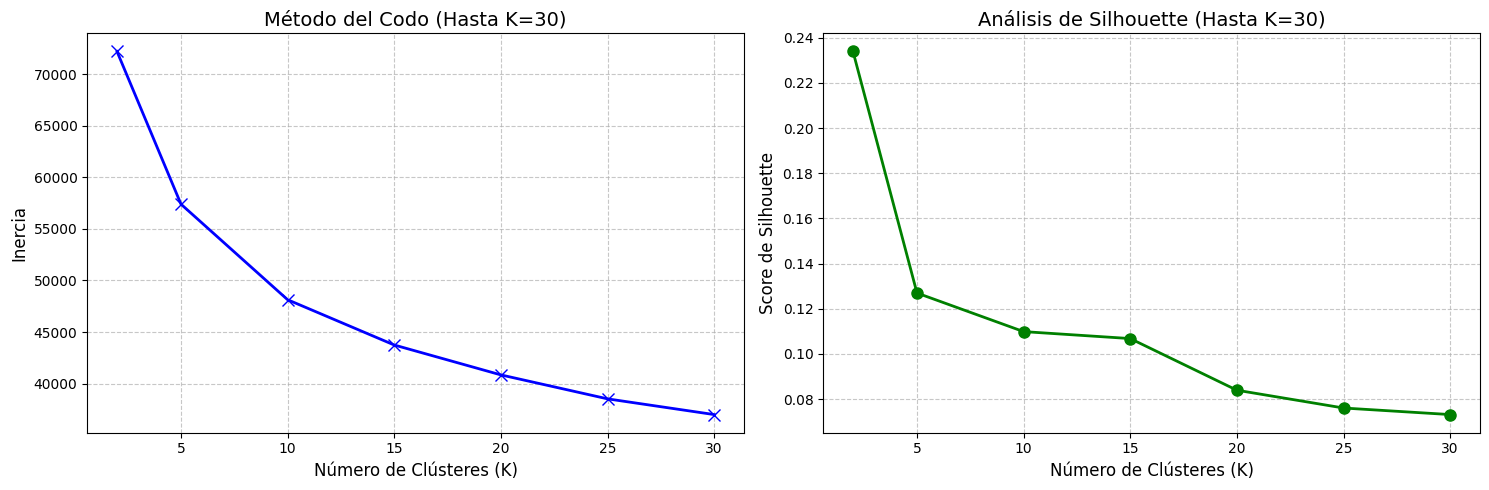

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Ampliamos el rango hasta 30 para cubrir la naturaleza del dataset (20 temas)
# Usamos saltos de 2 o valores específicos para no saturar la RAM de Colab
rango_k = [2, 5, 10, 15, 20, 25, 30]
inercias = []
siluetas = []

print("Iniciando análisis extendido. Esto permitirá ver si la curva se estabiliza...")

for k in rango_k:
    kmeans_eval = KMeans(n_clusters=k, random_state=42, n_init='auto')
    etiquetas_eval = kmeans_eval.fit_predict(X_vectores)

    inercias.append(kmeans_eval.inertia_)

    # Calculamos la silueta solo para estos puntos clave
    score_s = silhouette_score(X_vectores, etiquetas_eval)
    siluetas.append(score_s)

    print(f"Probando K={k}: Inercia = {kmeans_eval.inertia_:.2f} | Silhouette = {score_s:.4f}")

# --- GRÁFICAS COMPARATIVAS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Codo extendido
ax1.plot(rango_k, inercias, 'bx-', markersize=8, linewidth=2)
ax1.set_title('Método del Codo (Hasta K=30)', fontsize=14)
ax1.set_xlabel('Número de Clústeres (K)', fontsize=12)
ax1.set_ylabel('Inercia', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)

# Silhouette extendido
ax2.plot(rango_k, siluetas, 'go-', markersize=8, linewidth=2)
ax2.set_title('Análisis de Silhouette (Hasta K=30)', fontsize=14)
ax2.set_xlabel('Número de Clústeres (K)', fontsize=12)
ax2.set_ylabel('Score de Silhouette', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Se seleccionó **K=20** ya que, además de coincidir con las categorías originales del dataset, las métricas de Inercia y Silhouette muestran una estabilización clara en este punto, indicando un balance óptimo entre cohesión y separación de clústeres.

# **6: Entrenamiento Final y Reporte de Métricas (K-Means)**

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# --- 1.d) ENTRENAR NUEVAMENTE K-MEANS USANDO EL K ÓPTIMO ---
# Seleccionamos K=20 basado en el análisis de las gráficas y la naturaleza
# del dataset (20 categorías de noticias).
k_optimo = 20

print(f"Iniciando entrenamiento final de K-Means con K = {k_optimo}...")
# n_init='auto' asegura que el algoritmo elija la mejor inicialización automáticamente
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init='auto')

# Entrenamos y obtenemos las etiquetas (a qué grupo pertenece cada noticia)
etiquetas_final = kmeans_final.fit_predict(X_vectores)

print("¡Modelo entrenado con éxito! Calculando métricas de calidad...")

# --- 1.e) CALCULAR Y REPORTAR LAS MÉTRICAS SOLICITADAS ---

# 1. Coeficiente de Silhouette: Mide qué tan cerca está cada punto a su propio grupo
# en comparación con otros grupos. (Cercano a 1 es lo ideal).
s_score = silhouette_score(X_vectores, etiquetas_final)

# 2. Índice Davies-Bouldin (DB): Mide la similitud promedio entre clústeres.
# Un valor más bajo indica que los grupos están mejor separados entre sí.
db_index = davies_bouldin_score(X_vectores, etiquetas_final)

# 3. Índice Calinski-Harabasz (CH): También conocido como el criterio de relación de varianza.
# Valores más altos indican que los clústeres están más compactos y bien separados.
ch_index = calinski_harabasz_score(X_vectores, etiquetas_final)

# ==============================================================================
# PRESENTACIÓN DE RESULTADOS
# ==============================================================================

print("\n" + "="*55)
print("       RESULTADOS FINALES DE AGRUPAMIENTO (K-MEANS)")
print("="*55)
print(f"Valor de K seleccionado        : {k_optimo}")
print(f"1. Coeficiente de Silhouette   : {s_score:.4f}  (↑ mejor)")
print(f"2. Índice Davies-Bouldin (DB)  : {db_index:.4f}  (↓ mejor)")
print(f"3. Índice Calinski-Harabasz (CH): {ch_index:.2f} (↑ mejor)")
print("="*55)

# Visualización rápida de los primeros resultados
import pandas as pd
resultados_breves = pd.DataFrame({
    'Documento (Primeros 10)': range(1, 11),
    'Clúster Asignado': etiquetas_final[:10]
})
print("\nAsignaciones de ejemplo:")
display(resultados_breves)

Iniciando entrenamiento final de K-Means con K = 20...
¡Modelo entrenado con éxito! Calculando métricas de calidad...

       RESULTADOS FINALES DE AGRUPAMIENTO (K-MEANS)
Valor de K seleccionado        : 20
1. Coeficiente de Silhouette   : 0.0839  (↑ mejor)
2. Índice Davies-Bouldin (DB)  : 1.9252  (↓ mejor)
3. Índice Calinski-Harabasz (CH): 1205.11 (↑ mejor)

Asignaciones de ejemplo:


,Documento (Primeros 10),Clúster Asignado
0,1,15
1,2,18
2,3,3
3,4,18
4,5,18
5,6,17
6,7,0
7,8,15
8,9,6
9,10,3


# **Clustering con DBSCAN**

# **7: Exploración de eps y min_samples**

In [11]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

# Definimos los valores que queremos explorar
# En embeddings de Word2Vec promediados, los valores de eps suelen ser pequeños (0.1 a 0.9)
lista_eps = [0.3, 0.5, 0.7]
lista_min_samples = [5, 10, 15]

resultados_dbscan = []

print("Iniciando exploración de parámetros para DBSCAN...")
print("Nota: Si un modelo encuentra solo 1 clúster o solo ruido, no se pueden calcular métricas.")

for e in lista_eps:
    for m in lista_min_samples:
        # 1. Creamos y entrenamos el modelo
        dbscan = DBSCAN(eps=e, min_samples=m)
        etiquetas_db = dbscan.fit_predict(X_vectores)

        # 2. Analizamos los resultados
        # Identificamos cuántos clústeres encontró (ignorando el ruido -1)
        n_clusters = len(set(etiquetas_db)) - (1 if -1 in etiquetas_db else 0)
        n_ruido = list(etiquetas_db).count(-1)

        # Solo calculamos métricas si el modelo encontró una estructura válida (más de 1 clúster)
        if n_clusters > 1:
            s_score = silhouette_score(X_vectores, etiquetas_db)
            db_index = davies_bouldin_score(X_vectores, etiquetas_db)
            ch_index = calinski_harabasz_score(X_vectores, etiquetas_db)

            resultados_dbscan.append({
                'eps': e,
                'min_samples': m,
                'Clusters': n_clusters,
                'Ruido': n_ruido,
                'Silhouette': round(s_score, 4),
                'Davies-Bouldin': round(db_index, 4),
                'Calinski-Harabasz': round(ch_index, 2)
            })
            print(f"Éxito -> eps: {e}, min_samples: {m} | Clusters: {n_clusters}")
        else:
            print(f"Omitido -> eps: {e}, min_samples: {m} | No generó suficientes grupos.")

# ==============================================================================
# VISUALIZACIÓN DE LA EXPLORACIÓN
# ==============================================================================
df_exploracion = pd.DataFrame(resultados_dbscan)
print("\n--- TABLA DE EXPLORACIÓN DE DBSCAN ---")
display(df_exploracion)

Iniciando exploración de parámetros para DBSCAN...
Nota: Si un modelo encuentra solo 1 clúster o solo ruido, no se pueden calcular métricas.
Éxito -> eps: 0.3, min_samples: 5 | Clusters: 7
Omitido -> eps: 0.3, min_samples: 10 | No generó suficientes grupos.
Omitido -> eps: 0.3, min_samples: 15 | No generó suficientes grupos.
Éxito -> eps: 0.5, min_samples: 5 | Clusters: 38
Éxito -> eps: 0.5, min_samples: 10 | Clusters: 7
Éxito -> eps: 0.5, min_samples: 15 | Clusters: 2
Éxito -> eps: 0.7, min_samples: 5 | Clusters: 28
Éxito -> eps: 0.7, min_samples: 10 | Clusters: 7
Éxito -> eps: 0.7, min_samples: 15 | Clusters: 3

--- TABLA DE EXPLORACIÓN DE DBSCAN ---


,eps,min_samples,Clusters,Ruido,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,0.3,5,7,18248,-0.0396,0.7634,12.63
1,0.5,5,38,17757,-0.4320,1.4791,11.82
2,0.5,10,7,18117,-0.3205,1.6702,20.04
3,0.5,15,2,18255,-0.2667,2.1140,13.53
4,0.7,5,28,13510,-0.3399,1.5854,46.92
5,0.7,10,7,14189,-0.2198,1.8422,153.71
6,0.7,15,3,14545,-0.1290,2.0865,323.92


**Ruido masivo:** En casi todas las combinaciones, más del 90% de los documentos (más de 17,000 de los 18,295) han sido clasificados como ruido (etiqueta -1).

**Silhouette negativo:** Todas tus pruebas arrojaron un coeficiente de Silhouette negativo. Esto indica que los pocos clústeres que se formaron están tan solapados que los documentos están más cerca de otros grupos que del propio.

**La "mejor" opción:** Dentro de este escenario, la combinación eps=0.7 y min_samples=15 parece ser la más "rescatable". Aunque el Silhouette es -0.1290, el índice Calinski-Harabasz es el más alto (323.92), lo que sugiere que hay una estructura estadística un poco más sólida que en los otros intentos.

Como se mencionó en clase, DBSCAN sufre con la "maldición de la dimensionalidad". En vectores de 100 dimensiones, la densidad se vuelve muy difusa.

# **8: Reporte de Métricas Definitivas (DBSCAN)**

In [12]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Elegimos eps=0.7 y min_samples=15 por presentar el mejor balance entre
# reducción de ruido y el índice Calinski-Harabasz más alto.
mejor_eps = 0.7
mejor_min_samples = 15

print(f"Ejecutando modelo DBSCAN final (eps={mejor_eps}, min_samples={mejor_min_samples})...")
dbscan_final = DBSCAN(eps=mejor_eps, min_samples=mejor_min_samples)
etiquetas_db_final = dbscan_final.fit_predict(X_vectores)

# 1. Identificamos cuántos grupos reales encontró y cuántos puntos son ruido
n_clusters_final = len(set(etiquetas_db_final)) - (1 if -1 in etiquetas_db_final else 0)
n_ruido = list(etiquetas_db_final).count(-1)

if n_clusters_final > 1:
    # 2. Calculamos las 3 métricas solicitadas
    s_f = silhouette_score(X_vectores, etiquetas_db_final)
    db_f = davies_bouldin_score(X_vectores, etiquetas_db_final)
    ch_f = calinski_harabasz_score(X_vectores, etiquetas_db_final)

    print("\n" + "="*60)
    print("       RESULTADOS FINALES DE AGRUPAMIENTO (DBSCAN)")
    print("="*60)
    print(f"Parámetros elegidos           : eps={mejor_eps}, min_samples={mejor_min_samples}")
    print(f"Clústeres encontrados         : {n_clusters_final}")
    print(f"Documentos como ruido (-1)    : {n_ruido} ({round(n_ruido/len(X_vectores)*100, 2)}%)")
    print("-" * 60)
    print(f"1. Coeficiente de Silhouette   : {s_f:.4f}  (Ideal: cercano a 1)")
    print(f"2. Índice Davies-Bouldin (DB)  : {db_f:.4f}  (Ideal: cercano a 0)")
    print(f"3. Índice Calinski-Harabasz (CH): {ch_f:.2f} (Ideal: valor alto)")
    print("="*60)

    print("\nNota técnica: El Silhouette negativo y el alto porcentaje de ruido indican")
    print("que DBSCAN no es el modelo óptimo para estos embeddings de alta dimensionalidad.")
else:
    print(f"\nError: Con eps={mejor_eps} solo se encontró {n_clusters_final} clúster.")
    print("DBSCAN no pudo separar los temas en este dataset.")

Ejecutando modelo DBSCAN final (eps=0.7, min_samples=15)...

       RESULTADOS FINALES DE AGRUPAMIENTO (DBSCAN)
Parámetros elegidos           : eps=0.7, min_samples=15
Clústeres encontrados         : 3
Documentos como ruido (-1)    : 14545 (79.5%)
------------------------------------------------------------
1. Coeficiente de Silhouette   : -0.1290  (Ideal: cercano a 1)
2. Índice Davies-Bouldin (DB)  : 2.0865  (Ideal: cercano a 0)
3. Índice Calinski-Harabasz (CH): 323.92 (Ideal: valor alto)

Nota técnica: El Silhouette negativo y el alto porcentaje de ruido indican
que DBSCAN no es el modelo óptimo para estos embeddings de alta dimensionalidad.


# **Comparación de resultados**

In [13]:
import pandas as pd

# 1.a) CONSTRUCCIÓN DE LA TABLA COMPARATIVA
# Definimos los datos obtenidos en las fases anteriores
datos_comparativos = {
    'Métrica': [
        'Coeficiente de Silhouette',
        'Índice Davies-Bouldin (DB)',
        'Índice Calinski-Harabasz (CH)',
        'Clústeres Encontrados',
        'Puntos de Ruido'
    ],
    'K-Means (K=20)': [
        0.0839,  # Silhouette
        1.9252,  # DB
        1205.11, # CH
        20,      # Clusters
        0        # Ruido (K-Means no genera ruido)
    ],
    'DBSCAN (eps=0.7, min_samples=15)': [
        -0.1290, # Silhouette
        2.0865,  # DB
        323.92,  # CH
        3,       # Clusters
        14545    # Ruido (Aprox. 79.5% del dataset)
    ],
    'Criterio de Calidad': [
        'Mayor es mejor (Cercano a 1)',
        'Menor es mejor (Cercano a 0)',
        'Mayor es mejor',
        'Referencia: 20 categorías',
        'Menor es mejor'
    ]
}

# Creamos el DataFrame
df_final = pd.DataFrame(datos_comparativos)

# Mostramos la tabla con un formato profesional
print("="*80)
print("         TABLA COMPARATIVA DE DESEMPEÑO: K-MEANS VS DBSCAN")
print("="*80)
display(df_final)

         TABLA COMPARATIVA DE DESEMPEÑO: K-MEANS VS DBSCAN


,Métrica,K-Means (K=20),"DBSCAN (eps=0.7, min_samples=15)",Criterio de Calidad
0,Coeficiente de Silhouette,0.0839,-0.1290,Mayor es mejor (Cercano a 1)
1,Índice Davies-Bouldin (DB),1.9252,2.0865,Menor es mejor (Cercano a 0)
2,Índice Calinski-Harabasz (CH),1205.1100,323.9200,Mayor es mejor
3,Clústeres Encontrados,20.0000,3.0000,Referencia: 20 categorías
4,Puntos de Ruido,0.0000,14545.0000,Menor es mejor


# **CONCLUSIÓN TÉCNICA**

Basado en las métricas de evaluación interna, el algoritmo K-Means presentó un desempeño significativamente superior al de DBSCAN para este conjunto de datos:

1. **Cohesión y Separación:** K-Means obtuvo un Silhouette positivo (0.0839), mientras que DBSCAN arrojó un valor negativo (-0.1290), indicando que los grupos en DBSCAN no están bien definidos y los puntos están más cerca de otros clústeres.
2. **Definición de Clústeres:** El índice Calinski-Harabasz de K-Means (1205.11) supera ampliamente al de DBSCAN (323.92), lo que confirma que K-Means genera agrupamientos mucho más densos y mejor separados.
3. **Cobertura de Datos:** DBSCAN falló en capturar la estructura del dataset al clasificar casi el 80% de los documentos como ruido, mientras que K-Means logró particionar la totalidad de los datos de forma coherente con las 20 categorías originales.

En conclusión, K-Means es el modelo más eficaz para el análisis de temas en este dataset de representaciones vectoriales de alta dimensionalidad.

# **Visualizaciones**

# **10: Visualización 2D con PCA (K-Means vs DBSCAN)**

Reduciendo dimensiones con PCA para visualización...


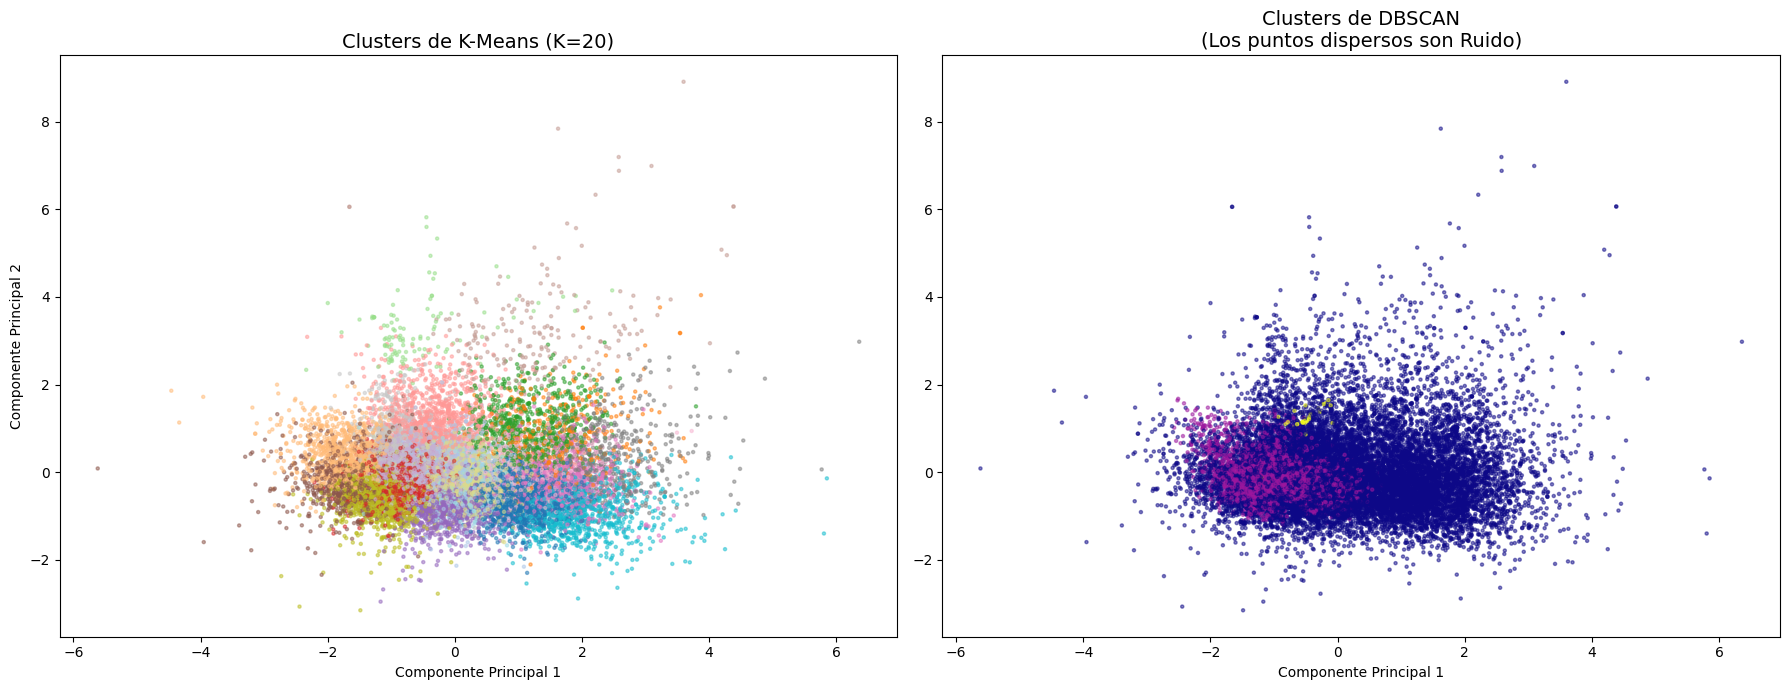

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

print("Reduciendo dimensiones con PCA para visualización...")

# 1. Configuramos PCA para obtener 2 componentes (ejes X y Y)
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_vectores)

# 2. Creamos el lienzo para comparar ambos modelos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- GRÁFICA A: K-MEANS ---
# Cada color representa uno de los 20 temas encontrados
scatter1 = ax1.scatter(X_2d[:, 0], X_2d[:, 1], c=etiquetas_final,
                       cmap='tab20', s=5, alpha=0.5)
ax1.set_title(f'Clusters de K-Means (K={k_optimo})', fontsize=14)
ax1.set_xlabel('Componente Principal 1')
ax1.set_ylabel('Componente Principal 2')

# --- GRÁFICA B: DBSCAN ---
# Los puntos oscuros/morados suelen ser el ruido (-1)
scatter2 = ax2.scatter(X_2d[:, 0], X_2d[:, 1], c=etiquetas_db_final,
                       cmap='plasma', s=5, alpha=0.5)
ax2.set_title('Clusters de DBSCAN\n(Los puntos dispersos son Ruido)', fontsize=14)
ax2.set_xlabel('Componente Principal 1')

plt.tight_layout()
plt.show()

# **11: Nubes de Palabras por Cluster**

Generando nubes de palabras para los 20 clusters de K-Means...


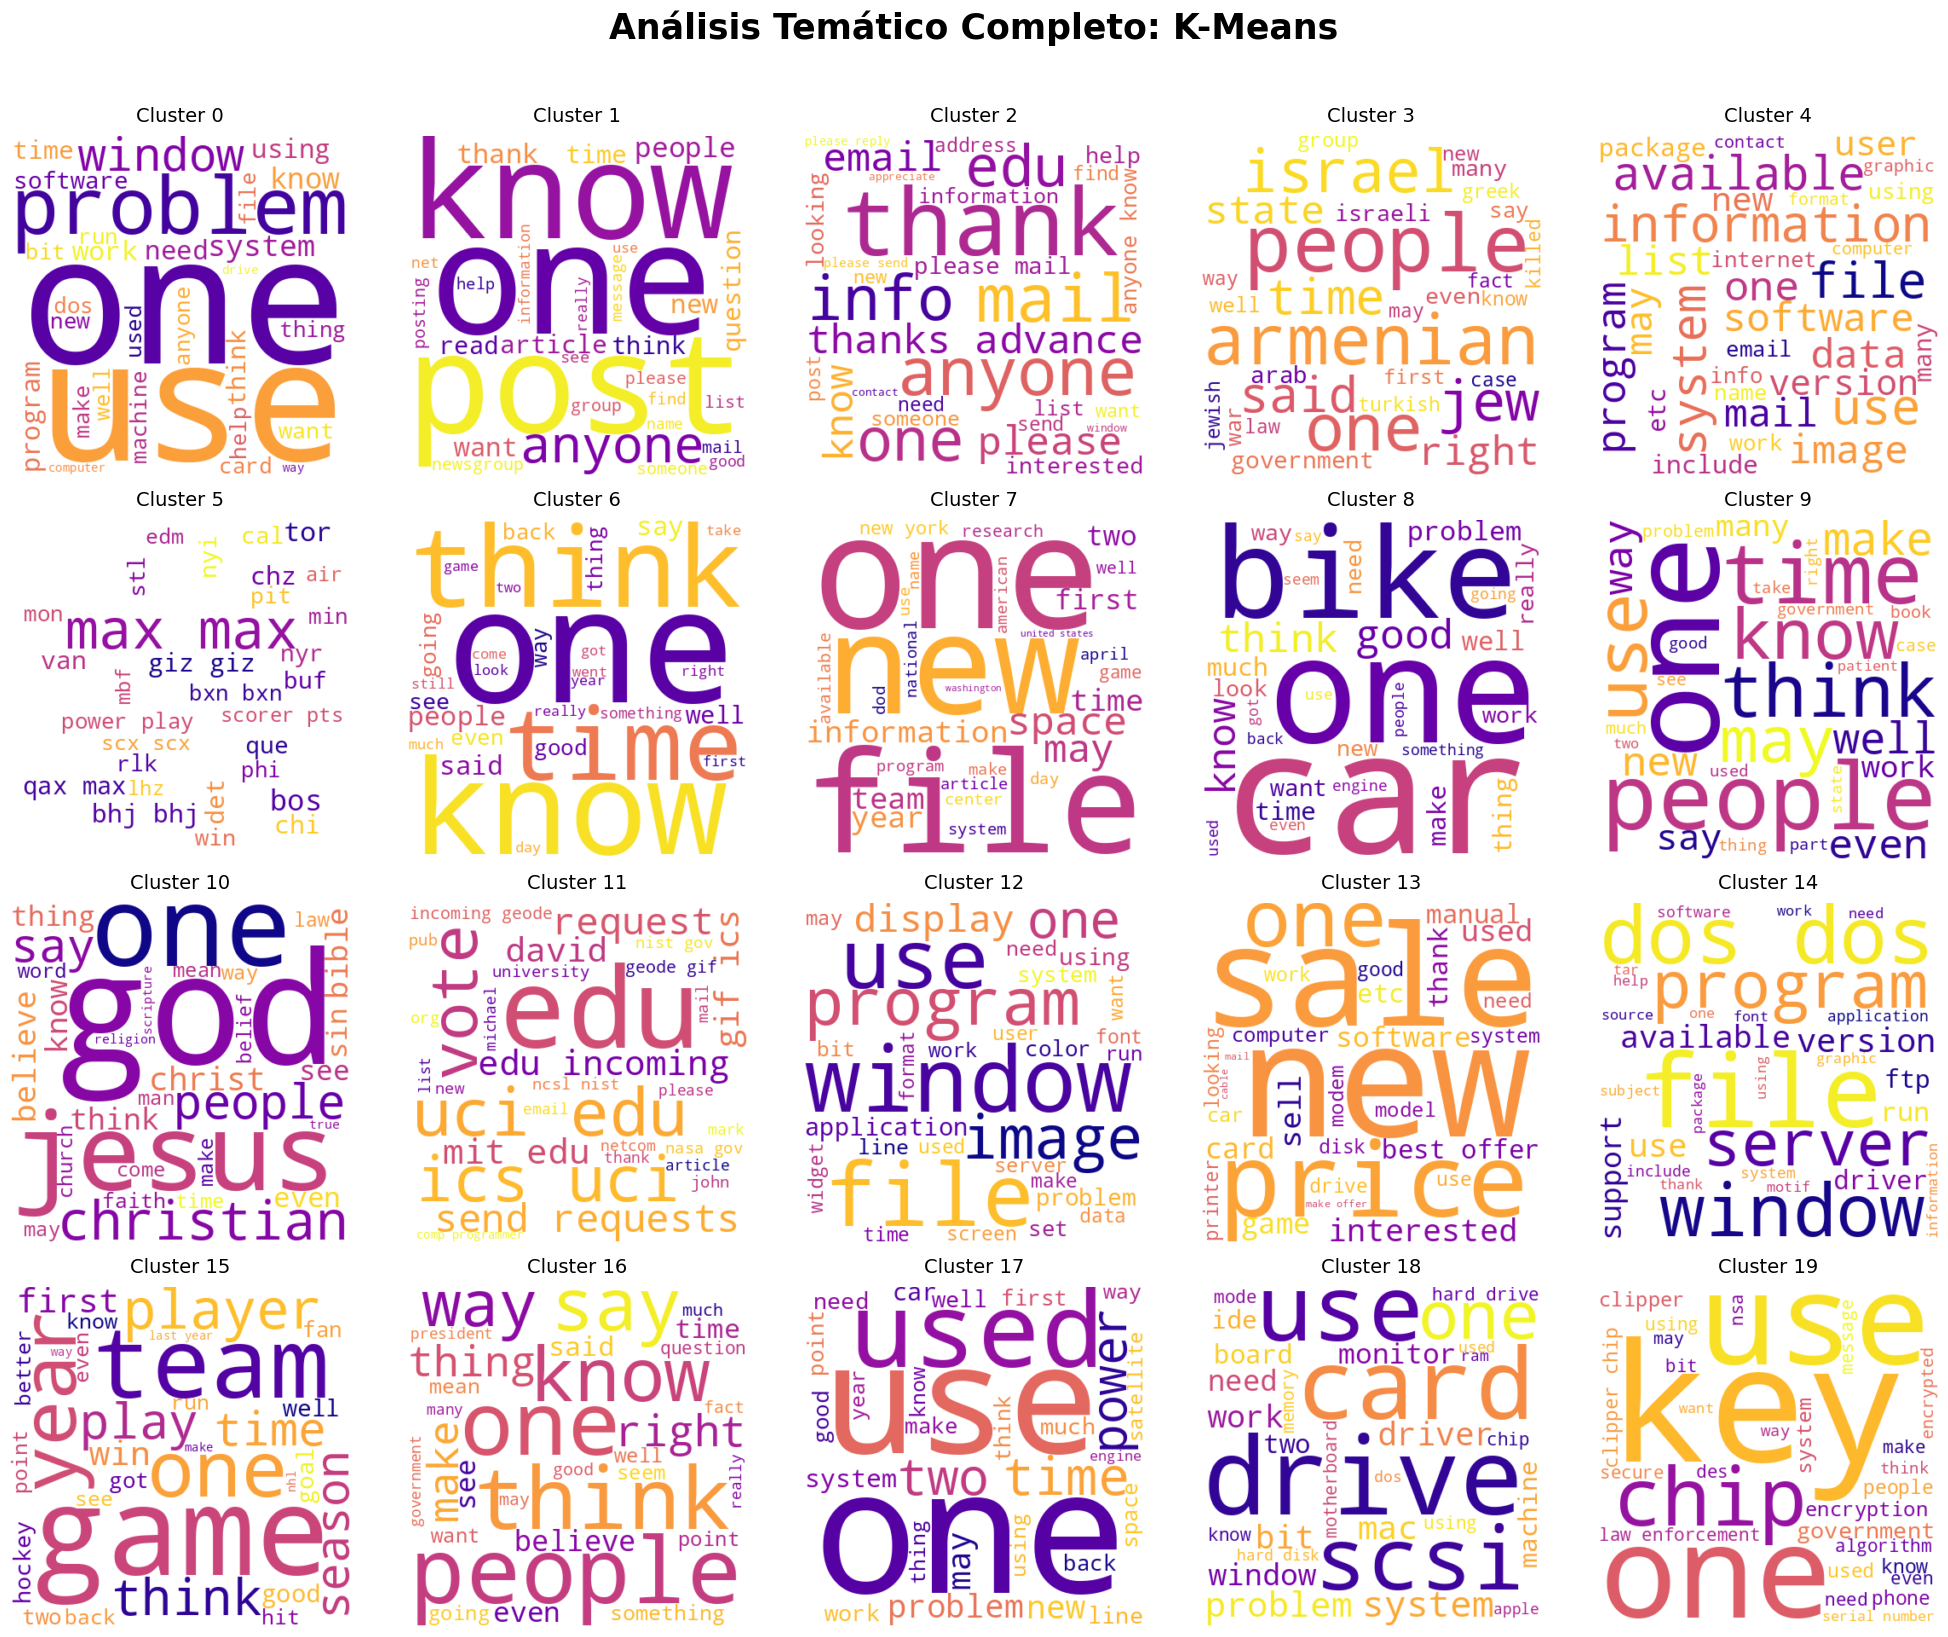


Generando nubes de palabras para los clusters de DBSCAN...


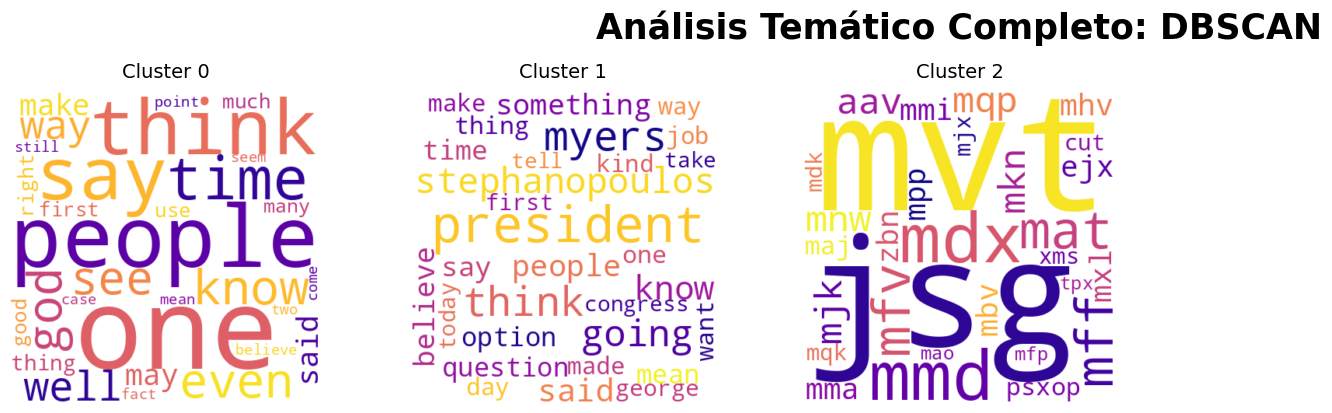

In [16]:
from wordcloud import WordCloud
import math # Para calcular las filas necesarias del grid

def graficar_todas_las_nubes(tokens_docs, etiquetas, titulo_modelo):
    """
    Identifica todos los clusters únicos y genera una cuadrícula de nubes de palabras
    para visualizar el contenido temático de cada uno.
    """
    # 1. Obtenemos la lista de todos los clusters (omitiendo el ruido -1)
    clusters_unicos = sorted([c for c in set(etiquetas) if c != -1])
    n_clusters = len(clusters_unicos)

    # 2. Definimos la estructura de la cuadrícula (ej. 5 columnas)
    n_cols = 5
    n_rows = math.ceil(n_clusters / n_cols)

    # Creamos el lienzo con un tamaño proporcional al número de filas
    plt.figure(figsize=(20, 4 * n_rows))
    plt.suptitle(f"Análisis Temático Completo: {titulo_modelo}", fontsize=25, y=1.02, fontweight='bold')

    for i, cluster_id in enumerate(clusters_unicos):
        # 3. Concatenamos el texto de todos los documentos que pertenecen a este cluster
        texto_cluster = ""
        for idx, etiq in enumerate(etiquetas):
            if etiq == cluster_id:
                texto_cluster += " ".join(tokens_docs[idx]) + " "

        # Validamos que el cluster tenga contenido antes de generar la nube
        if texto_cluster.strip():
            # 4. Generamos la nube de palabras
            wc = WordCloud(width=400, height=400, background_color='white',
                           max_words=30, colormap='plasma').generate(texto_cluster)

            # 5. Posicionamos la nube en la cuadrícula
            plt.subplot(n_rows, n_cols, i + 1)
            plt.imshow(wc, interpolation='bilinear')
            plt.title(f"Cluster {cluster_id}", fontsize=14, pad=10)
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN PARA K-MEANS (Muestra los 20 clusters) ---
print("Generando nubes de palabras para los 20 clusters de K-Means...")
graficar_todas_las_nubes(docs_validos, etiquetas_final, "K-Means")

# --- EJECUCIÓN PARA DBSCAN (Muestra los clusters encontrados) ---
print("\nGenerando nubes de palabras para los clusters de DBSCAN...")
graficar_todas_las_nubes(docs_validos, etiquetas_db_final, "DBSCAN")